# Part 2 — Image-Level Predictors of Consistency

Tests what distinguishes a highly-consistent image from a poorly-consistent
one. Two candidate predictors are tested: response sparsity/magnitude (neural,
from Part 1 outputs) and CNN-based image complexity (ResNet50 layer embeddings,
from the preprocessed archive). Partial Spearman correlation establishes
whether CNN complexity predicts consistency *independently* of sparsity.

**Depends on:** `part1_outputs.npz`, `cnn_embeddings.npz`

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(".").resolve()))
from utils import (
    setup_archive,
    window_response,
    compute_similarity_matrices,
    per_image_consistency,
    cluster_bootstrap_ci,
    apply_plot_style,
    ts_ratio,
    print_figure_data,
)

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler

SEED = 42
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 9.5, 'figure.dpi': 150,
})
sns.set_style('ticks')
COL_NS  = 'steelblue'
COL_GR  = 'darkorange'
COL_FIT = 'firebrick'
COL_REF = 'dimgray'


colors  = apply_plot_style()
COL_NS  = colors["COL_NS"]
COL_GR  = colors["COL_GR"]
COL_FIT = colors["COL_FIT"]
COL_REF = colors["COL_REF"]

In [3]:
# Load archive, extract if needed, resolve output paths.
manifest, bin_edges, ARCHIVE_DIR, FIGURES_DIR, OUTPUTS_DIR = setup_archive(
    zip_path    = '../preprocessed_data.zip',
    archive_dir = '../preprocessed_data',
    figures_dir = '../figures',
    outputs_dir = '.',
)
N_IMAGES = manifest['n_images']

p1 = np.load(OUTPUTS_DIR / 'part1_outputs.npz')
consistency    = p1['consistency']       # (118,)
mean_sparsity  = p1['mean_sparsity']    # (118,)
mean_magnitude = p1['mean_magnitude']   # (118,)

cnn_data    = np.load(ARCHIVE_DIR / 'cnn_embeddings.npz')
layer_names = ['layer1', 'layer2', 'layer3', 'layer4', 'final']
layer_emb   = {name: cnn_data[name] for name in layer_names}

print(f'Images: {N_IMAGES}')
print(f'Consistency range: [{consistency.min():.3f}, {consistency.max():.3f}]')
print(f'CNN layers: {[(k, v.shape) for k, v in layer_emb.items()]}')

Archive already extracted: C:\Users\janak\GitHub\cross-mouse-v1-rsa\preprocessed_data
Manifest: 32 VISp sessions | 118 images | 479 bins × 1 ms
Images: 118
Consistency range: [0.142, 0.588]
CNN layers: [('layer1', (118, 256)), ('layer2', (118, 512)), ('layer3', (118, 1024)), ('layer4', (118, 2048)), ('final', (118, 1000))]


## 2.1 — Sparsity and magnitude as image-level predictors

Sparsity is defined as the fraction of units responding below the per-mouse
median absolute z-score — a threshold-free measure robust to session-level
differences in overall firing rate. Both predictors were averaged across mice
(already done in Part 1) before correlating with consistency.

In [4]:
r_sp,  p_sp  = spearmanr(consistency, mean_sparsity)
r_mag, p_mag = spearmanr(consistency, mean_magnitude)
print(f'Consistency vs. sparsity  : r = {r_sp:+.3f},  p = {p_sp:.2e}')
print(f'Consistency vs. magnitude : r = {r_mag:+.3f},  p = {p_mag:.2e}')

Consistency vs. sparsity  : r = -0.470,  p = 7.84e-08
Consistency vs. magnitude : r = +0.276,  p = 2.51e-03


## 2.2 — CNN feature embeddings

ResNet50 pretrained on ImageNet (IMAGENET1K_V2) is used as a feature
extractor. Global average pooling reduces each convolutional block to a
fixed-length vector per image. Ridge LOO regression (n=118 images) is used
because feature dimension >> n_images makes OLS ill-posed.

Two separate CNN quantities are tested against sparsity, and they should not
be conflated:
- `cnn_proxy`, a scalar (per-image mean activation of layer 2) — a weak
  raw predictor (r ~ -0.02) — used only as a quick diagnostic below.
- `layer_results['layer2']['y_pred']`, the full 512-dim ridge LOO
  prediction (r = -0.496) — this is the actual predictive CNN signal, and
  it is this quantity, not the scalar proxy, that must be tested for
  independence from sparsity.

In [5]:
CNN_PRIMARY = 'layer2'   # best single-layer predictor

layer_results = {}
for name, emb in layer_emb.items():
    Xs     = StandardScaler().fit_transform(emb)
    loo    = LeaveOneOut()
    y_pred = cross_val_predict(
        RidgeCV(alphas=np.logspace(-2, 6, 30)), Xs, consistency, cv=loo)
    r, p   = pearsonr(consistency, y_pred)
    layer_results[name] = {'r': r, 'r2': r**2, 'p': p, 'y_pred': y_pred}
    print(f'{name:>8s}: LOO r = {r:+.3f},  R² = {r**2:.3f},  p = {p:.2e}')


def partial_spearman(x, y, cov):
    """Non-parametric partial correlation via rank-residualisation."""
    def resid(a, b):
        ar = pd.Series(a).rank().values.astype(float)
        br = pd.Series(b).rank().values.astype(float)
        return ar - LinearRegression().fit(
            br.reshape(-1, 1), ar).predict(br.reshape(-1, 1))
    return spearmanr(resid(x, cov), resid(y, cov))


# ── Diagnostic only: scalar mean-activation proxy (weak raw predictor) ────────
cnn_proxy   = layer_emb[CNN_PRIMARY].mean(axis=1)   # scalar per image
r_raw, p_raw = spearmanr(cnn_proxy, consistency)
r_par, p_par = partial_spearman(cnn_proxy, consistency, mean_sparsity)

print(f'\n[diagnostic] {CNN_PRIMARY} mean activation (scalar proxy) vs consistency:')
print(f'  Raw Spearman r            : {r_raw:+.3f},  p = {p_raw:.2e}')
print(f'  Partial r (sparsity ctrl) : {r_par:+.3f},  p = {p_par:.2e}')

# ── Headline test: does the full CNN model (LOO prediction) retain signal ─────
# ── after controlling for sparsity? ───────────────────────────────────────────
cnn_pred = layer_results[CNN_PRIMARY]['y_pred']   # full 512-dim ridge LOO prediction
r_par_full, p_par_full = partial_spearman(cnn_pred, consistency, mean_sparsity)

r2_sparsity_only = LinearRegression().fit(
    mean_sparsity.reshape(-1, 1), consistency).score(
    mean_sparsity.reshape(-1, 1), consistency)
X_nested = np.column_stack([mean_sparsity, cnn_pred])
r2_sparsity_plus_cnn = LinearRegression().fit(
    X_nested, consistency).score(X_nested, consistency)

print(f'\n{CNN_PRIMARY} full LOO-prediction vs consistency:')
print(f'  Raw LOO Pearson r                  : {layer_results[CNN_PRIMARY]["r"]:+.3f}')
print(f'  Partial r (sparsity ctrl)          : {r_par_full:+.3f},  p = {p_par_full:.2e}')
print(f'  R² sparsity alone                  : {r2_sparsity_only:.3f}')
print(f'  R² sparsity + CNN LOO prediction   : {r2_sparsity_plus_cnn:.3f}')
print(f'  Delta R² from adding CNN prediction : {r2_sparsity_plus_cnn - r2_sparsity_only:+.3f}')

  layer1: LOO r = -0.298,  R² = 0.089,  p = 1.03e-03
  layer2: LOO r = -0.496,  R² = 0.246,  p = 1.11e-08
  layer3: LOO r = -0.182,  R² = 0.033,  p = 4.90e-02
  layer4: LOO r = -0.243,  R² = 0.059,  p = 8.09e-03
   final: LOO r = -0.486,  R² = 0.236,  p = 2.48e-08

[diagnostic] layer2 mean activation (scalar proxy) vs consistency:
  Raw Spearman r            : -0.017,  p = 8.55e-01
  Partial r (sparsity ctrl) : +0.094,  p = 3.13e-01

layer2 full LOO-prediction vs consistency:
  Raw LOO Pearson r                  : -0.496
  Partial r (sparsity ctrl)          : -0.828,  p = 5.47e-31
  R² sparsity alone                  : 0.269
  R² sparsity + CNN LOO prediction   : 0.453
  Delta R² from adding CNN prediction : +0.184


## Added-variable analysis

Added-variable plots show the partial effect of each predictor after
controlling for the other. These are residualised against
`layer_results['layer2']['y_pred']` (the full 512-dim ridge LOO prediction),
not the scalar `cnn_proxy`, since it is the full model that carries the
actual predictive signal being dissociated from sparsity.

In [6]:
def ols_resid(y, x):
    """Residuals of y ~ x (OLS, with intercept)."""
    X_ = np.column_stack([np.ones(len(x)), x])
    b  = np.linalg.lstsq(X_, y, rcond=None)[0]
    return y - X_ @ b

resid_cons_vs_cnn     = ols_resid(consistency,  cnn_pred)
resid_sp_vs_cnn       = ols_resid(mean_sparsity, cnn_pred)
resid_cons_vs_sp      = ols_resid(consistency,  mean_sparsity)
resid_cnn_vs_sp       = ols_resid(cnn_pred,      mean_sparsity)

r_av_sp,  _ = pearsonr(resid_sp_vs_cnn,  resid_cons_vs_cnn)
r_av_cnn, _ = pearsonr(resid_cnn_vs_sp,  resid_cons_vs_sp)
print(f'Added-variable partial r — sparsity | CNN (full LOO pred) : {r_av_sp:+.3f}')
print(f'Added-variable partial r — CNN (full LOO pred) | sparsity : {r_av_cnn:+.3f}')

Added-variable partial r — sparsity | CNN (full LOO pred) : -0.523
Added-variable partial r — CNN (full LOO pred) | sparsity : -0.501


---
## Figures

**Fig. 2** (2×2) — Response sparsity, not image complexity, predicts cross-mouse
consistency. A: sparsity. B: magnitude. C: LOO accuracy by ResNet50 layer
(justifies the layer-2 choice used in D). D: the full CNN model's signal
survives controlling for sparsity (added-variable partial r), with the
nested-R² gain annotated.

**S2** — Partial-correlation robustness detail: (A) the residual scatter
clouds underlying Fig. 2D's bars, (B) a second, non-parametric partialling
method (rank-residualized Spearman), and (C) a nested-R² summary table
comparing both partialling methods side by side.


Fig 2A — consistency vs. response sparsity

--- mean_sparsity ---
shape=(118,)
[0.520492 0.546472 0.482891 0.457203 0.508473 0.426674 0.487684 0.54445  0.519074 0.517934 0.565284 0.59953  0.554183 0.459788 0.480241 0.480375 0.515295 0.42606  0.433015 0.412091]
...[118 elements total]

--- consistency ---
shape=(118,)
[0.422874 0.150347 0.320186 0.409948 0.482925 0.359236 0.40502  0.163267 0.260908 0.19579  0.275605 0.248535 0.290777 0.303716 0.260574 0.379713 0.378248 0.45102  0.32783  0.369047]
...[118 elements total]

--- spearman_r ---
-0.47008790478381707

--- spearman_p ---
7.837762738778081e-08

Fig 2B — consistency vs. response magnitude

--- mean_magnitude ---
shape=(118,)
[0.622436 0.661972 0.758902 0.881167 0.644245 0.967838 0.806265 0.688401 0.752618 0.738666 0.623841 0.584964 0.625305 0.868559 0.752002 0.840273 0.762268 0.911898 0.876095 1.054934]
...[118 elements total]

--- consistency ---
shape=(118,)
[0.422874 0.150347 0.320186 0.409948 0.482925 0.359236 0.40502  0.163

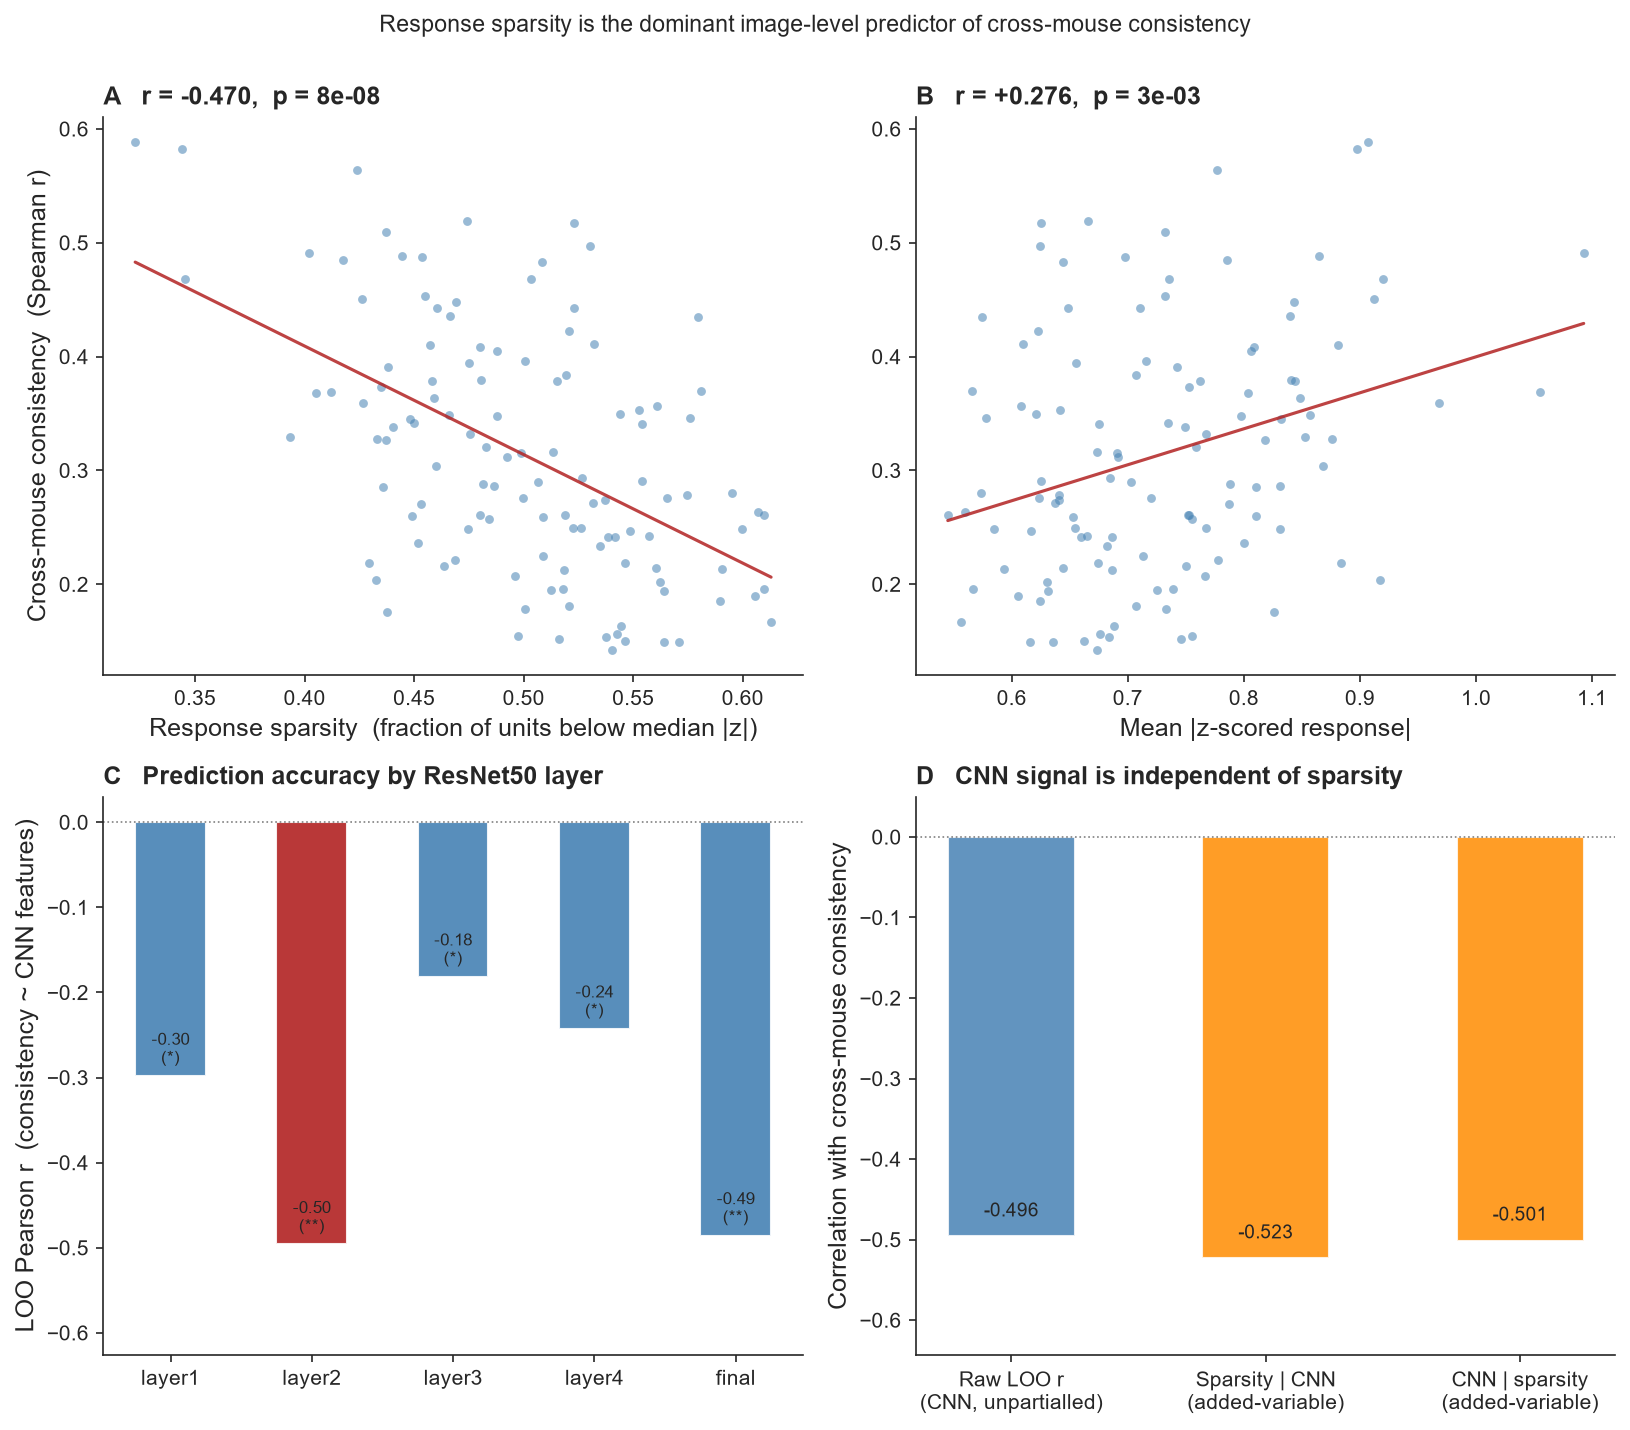

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9.5))
axA, axB = axes[0]
axC, axD = axes[1]

def scatter_with_fit(ax, x, y, r, p, xlabel, title_letter, color=COL_NS):
    ax.scatter(x, y, s=18, alpha=0.55, color=color, linewidths=0)
    m, b = np.polyfit(x, y, 1)
    xr   = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m * xr + b, color=COL_FIT, linewidth=1.5, alpha=0.85)
    ax.set_xlabel(xlabel)
    ax.set_title(f'{title_letter}   r = {r:+.3f},  p = {p:.0e}',
                 loc='left', fontweight='bold', pad=6)
    ax.spines[['top', 'right']].set_visible(False)

axA.set_ylabel('Cross-mouse consistency  (Spearman r)')
scatter_with_fit(axA, mean_sparsity, consistency, r_sp, p_sp,
                 'Response sparsity  (fraction of units below median |z|)', 'A')
scatter_with_fit(axB, mean_magnitude, consistency, r_mag, p_mag,
                 'Mean |z-scored response|', 'B')

# Panel C: LOO r per ResNet50 layer — justifies picking layer 2 as the CNN predictor
r_vals  = [layer_results[l]['r'] for l in layer_names]
p_vals  = [layer_results[l]['p'] for l in layer_names]
layer_colors = [COL_FIT if l == CNN_PRIMARY else
                (COL_NS if p < 0.05 else 'lightsteelblue')
                for l, p in zip(layer_names, p_vals)]
bars = axC.bar(layer_names, r_vals, color=layer_colors, alpha=0.9, width=0.5)
for bar, r, p in zip(bars, r_vals, p_vals):
    sig = '**' if p < 0.001 else ('*' if p < 0.05 else 'n.s.')
    axC.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.01,
             f'{r:.2f}\n({sig})', ha='center', va='bottom', fontsize=8)
axC.axhline(0, color='gray', linestyle=':', linewidth=0.8)
axC.set_ylim(min(r_vals) - 0.13, 0.03)
axC.set_ylabel('LOO Pearson r  (consistency ~ CNN features)')
axC.set_title('C   Prediction accuracy by ResNet50 layer',
              loc='left', fontweight='bold', pad=6)
axC.spines[['top', 'right']].set_visible(False)

# Panel D: independence from sparsity — raw LOO r vs. added-variable partial r (both directions)
bar_vals   = [layer_results[CNN_PRIMARY]['r'], r_av_sp, r_av_cnn]
bar_labels = ['Raw LOO r\n(CNN, unpartialled)',
              'Sparsity | CNN\n(added-variable)',
              'CNN | sparsity\n(added-variable)']
bar_colors = [COL_NS, COL_GR, COL_GR]
bars = axD.bar(bar_labels, bar_vals, color=bar_colors, alpha=0.85, width=0.5)
for bar, v in zip(bars, bar_vals):
    axD.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
             f'{v:+.3f}', ha='center', va='bottom', fontsize=9)
axD.axhline(0, color='gray', linestyle=':', linewidth=0.8)
axD.set_ylim(min(bar_vals) - 0.12, 0.05)
axD.set_ylabel('Correlation with cross-mouse consistency')
axD.set_title('D   CNN signal is independent of sparsity',
              loc='left', fontweight='bold', pad=6)
axD.spines[['top', 'right']].set_visible(False)

fig.suptitle('Response sparsity is the dominant image-level predictor of cross-mouse consistency',
             fontsize=11, y=1.0)

print_figure_data(
    'Fig 2A — consistency vs. response sparsity',
    mean_sparsity=mean_sparsity,
    consistency=consistency,
    spearman_r=r_sp,
    spearman_p=p_sp,
)
print_figure_data(
    'Fig 2B — consistency vs. response magnitude',
    mean_magnitude=mean_magnitude,
    consistency=consistency,
    spearman_r=r_mag,
    spearman_p=p_mag,
)
print_figure_data(
    'Fig 2C — LOO Pearson r per ResNet50 layer',
    layer_names=layer_names,
    loo_r_per_layer=np.array(r_vals),
    p_per_layer=np.array(p_vals),
)
print_figure_data(
    f'Fig 2D — CNN ({CNN_PRIMARY}) raw LOO r vs. added-variable partial r (sparsity controlled)',
    bar_labels=bar_labels,
    bar_values=np.array(bar_vals),
    r2_sparsity_only=r2_sparsity_only,
    r2_sparsity_plus_cnn=r2_sparsity_plus_cnn,
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_image_predictors.png', bbox_inches='tight')
plt.show()


Fig S2AB — added-variable residual scatter clouds (sparsity | CNN and CNN | sparsity)

--- sparsity_residual_given_cnn ---
shape=(118,)
[ 0.024906  0.045171 -0.013089 -0.028733  0.014612 -0.07204  -0.007331  0.041812  0.019649  0.017499  0.057528  0.099719  0.05332  -0.040015 -0.019195 -0.018141  0.017381 -0.071321 -0.058263
 -0.086466]
...[118 elements total]

--- consistency_residual_given_cnn ---
shape=(118,)
[ 0.081258 -0.153536 -0.01883   0.004606  0.129919  0.038273  0.059627 -0.131785 -0.055364 -0.113809  0.01435  -0.065181 -0.015994 -0.010055 -0.055622  0.057443  0.052005  0.121248 -0.042243
  0.047047]
...[118 elements total]

--- partial_r_sparsity_given_cnn ---
-0.5233756212223201

--- cnn_residual_given_sparsity ---
shape=(118,)
[-0.002843  0.000416 -0.002149 -0.008116 -0.003777  0.000228 -0.002809  0.001275 -0.000429  0.000216  0.004224 -0.001146  0.000051  0.000514  0.000041 -0.000535 -0.001327 -0.000597 -0.004492
  0.000304]
...[118 elements total]

--- consistency_resi

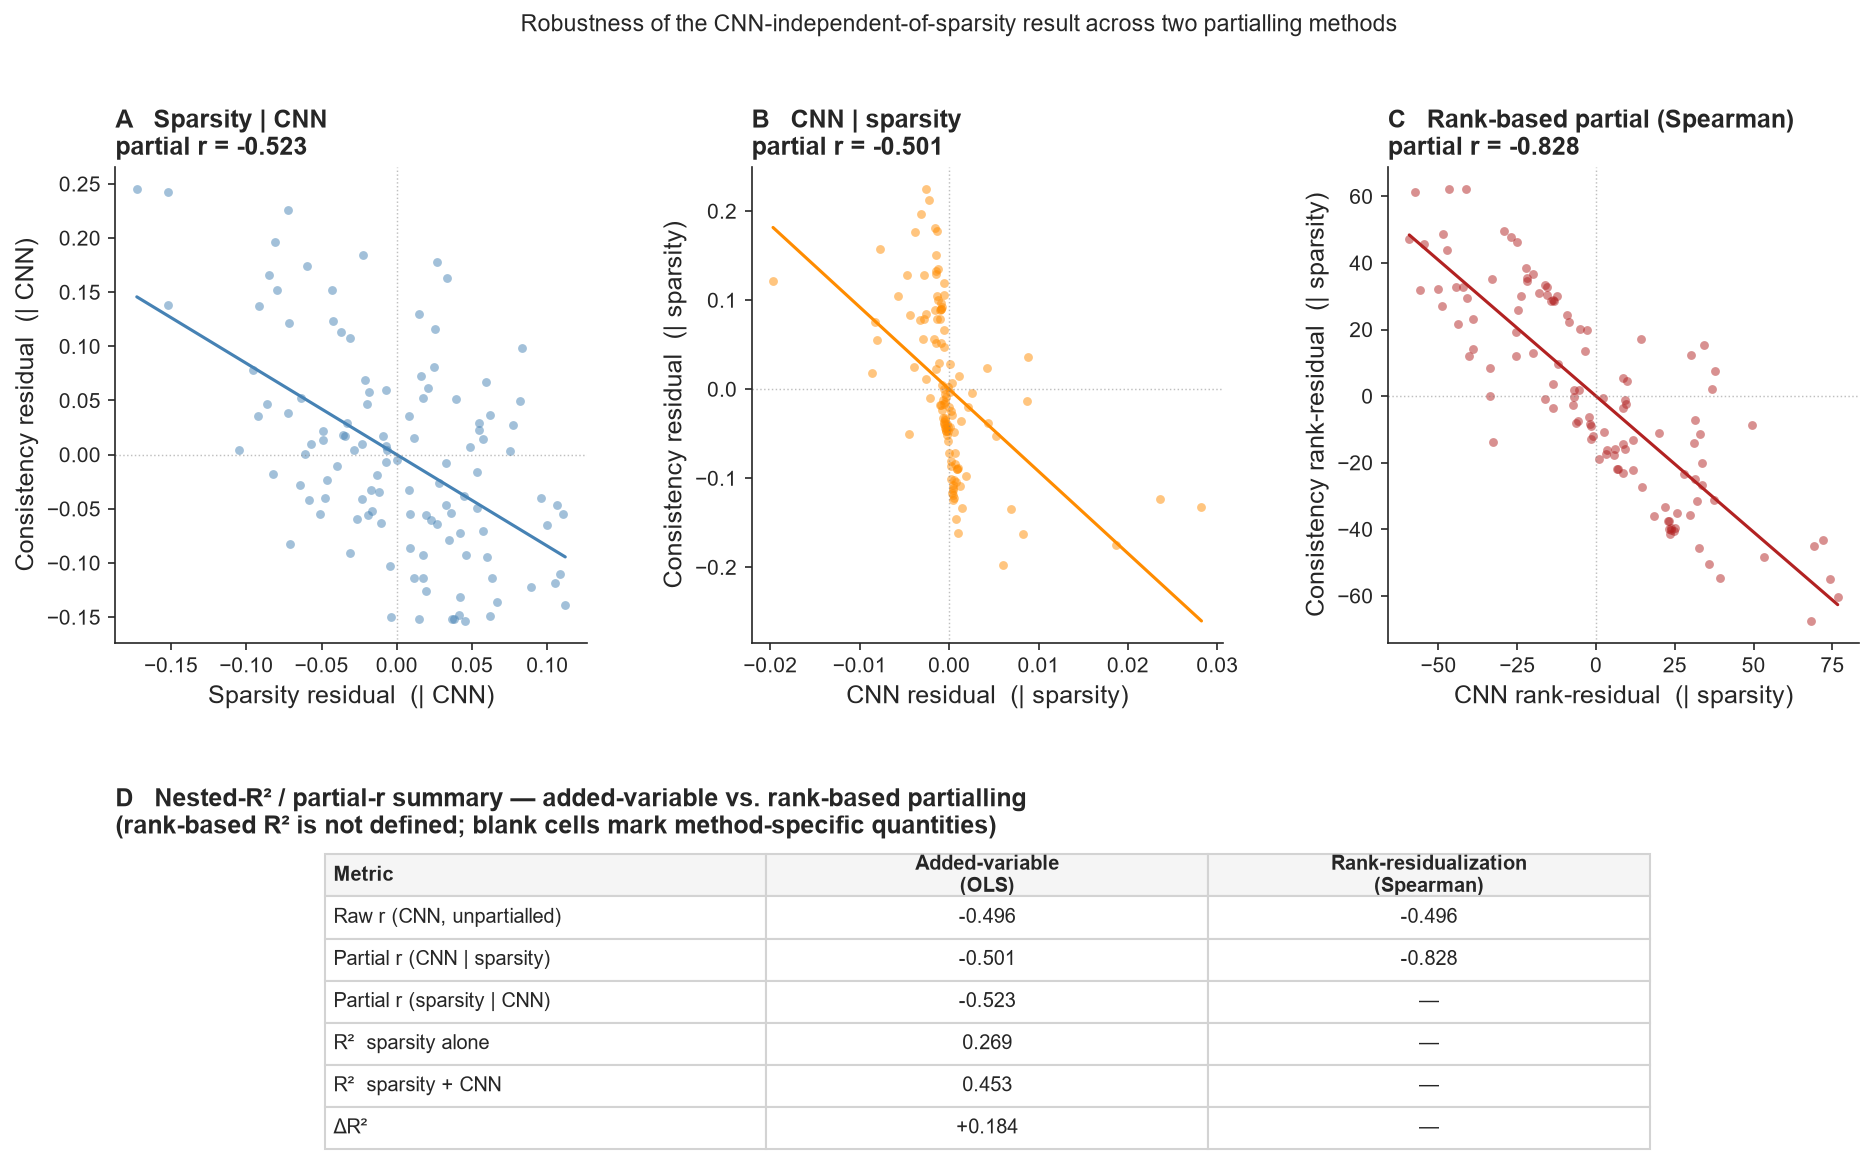

In [8]:
def rank_resid(a, b):
    """Rank-residualise a on b (used for the Spearman partial correlation)."""
    ar = pd.Series(a).rank().values.astype(float)
    br = pd.Series(b).rank().values.astype(float)
    return ar - LinearRegression().fit(br.reshape(-1, 1), ar).predict(br.reshape(-1, 1))

fig = plt.figure(figsize=(15, 8.5))
gs  = fig.add_gridspec(2, 3, height_ratios=[1, 0.62], hspace=0.55, wspace=0.35)
axA1 = fig.add_subplot(gs[0, 0])
axA2 = fig.add_subplot(gs[0, 1])
axB  = fig.add_subplot(gs[0, 2])
axC  = fig.add_subplot(gs[1, :])
axC.axis('off')

def resid_scatter(ax, x, y, r, color, xlabel, ylabel, title):
    ax.scatter(x, y, s=18, alpha=0.5, color=color, linewidths=0)
    m, b = np.polyfit(x, y, 1)
    xr   = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m * xr + b, color=color, linewidth=1.5)
    ax.axhline(0, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
    ax.axvline(0, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}\npartial r = {r:+.3f}', loc='left', fontweight='bold', pad=6)
    ax.spines[['top', 'right']].set_visible(False)

# Panel A — the two added-variable residual clouds underlying Fig 2D's bars
resid_scatter(axA1, resid_sp_vs_cnn, resid_cons_vs_cnn, r_av_sp, COL_NS,
              'Sparsity residual  (| CNN)', 'Consistency residual  (| CNN)',
              'A   Sparsity | CNN')
resid_scatter(axA2, resid_cnn_vs_sp, resid_cons_vs_sp, r_av_cnn, COL_GR,
              'CNN residual  (| sparsity)', 'Consistency residual  (| sparsity)',
              "B   CNN | sparsity")

# Panel B — rank-based (Spearman) partial correlation: an independent, non-parametric
# partialling method. Larger magnitude than the added-variable r's in Fig 2D; this is
# expected of a partial suppressor (sparsity shares variance with both consistency and
# the CNN prediction, so removing it from both sharpens their residual alignment).
# Convergent with Fig 2D (same conclusion: CNN carries independent signal) but not
# identical (different magnitude, different method).
rank_resid_cnn  = rank_resid(cnn_pred, mean_sparsity)
rank_resid_cons = rank_resid(consistency, mean_sparsity)
resid_scatter(axB, rank_resid_cnn, rank_resid_cons, r_par_full, COL_FIT,
              'CNN rank-residual  (| sparsity)', 'Consistency rank-residual  (| sparsity)',
              'C   Rank-based partial (Spearman)')

# Panel C — belt-and-suspenders nested-R² / partial-r summary, both methods side by side
table_rows = [
    ['Raw r (CNN, unpartialled)',            f'{layer_results[CNN_PRIMARY]["r"]:+.3f}', f'{layer_results[CNN_PRIMARY]["r"]:+.3f}'],
    ['Partial r (CNN | sparsity)',           f'{r_av_cnn:+.3f}',                        f'{r_par_full:+.3f}'],
    ['Partial r (sparsity | CNN)',           f'{r_av_sp:+.3f}',                         '—'],
    ['R²  sparsity alone',              f'{r2_sparsity_only:.3f}',                 '—'],
    ['R²  sparsity + CNN',              f'{r2_sparsity_plus_cnn:.3f}',             '—'],
    ['ΔR²',                        f'{r2_sparsity_plus_cnn - r2_sparsity_only:+.3f}', '—'],
]
col_labels = ['Metric', 'Added-variable\n(OLS)', 'Rank-residualization\n(Spearman)']
tbl = axC.table(cellText=table_rows, colLabels=col_labels,
                 cellLoc='center', colLoc='center', loc='center',
                 bbox=[0.12, 0.0, 0.76, 1.0])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('lightgray')
    if row == 0:
        cell.set_text_props(fontweight='bold')
        cell.set_facecolor('whitesmoke')
    if col == 0:
        cell.set_text_props(ha='left')
        cell.PAD = 0.02
axC.set_title('D   Nested-R² / partial-r summary — added-variable vs. rank-based partialling\n'
              '(rank-based R² is not defined; blank cells mark method-specific quantities)',
              loc='left', fontweight='bold', pad=10)

fig.suptitle('Robustness of the CNN-independent-of-sparsity result across two partialling methods',
             fontsize=11, y=1.0)

print_figure_data(
    'Fig S2AB — added-variable residual scatter clouds (sparsity | CNN and CNN | sparsity)',
    sparsity_residual_given_cnn=resid_sp_vs_cnn,
    consistency_residual_given_cnn=resid_cons_vs_cnn,
    partial_r_sparsity_given_cnn=r_av_sp,
    cnn_residual_given_sparsity=resid_cnn_vs_sp,
    consistency_residual_given_sparsity=resid_cons_vs_sp,
    partial_r_cnn_given_sparsity=r_av_cnn,
)
print_figure_data(
    'Fig S2C — rank-based (Spearman) partial correlation, CNN | sparsity',
    cnn_rank_residual=rank_resid_cnn,
    consistency_rank_residual=rank_resid_cons,
    partial_spearman_r=r_par_full,
    partial_spearman_p=p_par_full,
)
print_figure_data(
    'Fig S2D — nested R² / partial-r summary table',
    table_rows=np.array(table_rows),
    col_labels=np.array(col_labels),
)

plt.savefig(FIGURES_DIR / 'figS2_cnn_detail.png', bbox_inches='tight')
plt.show()